# ITEC5920 - Assignment 3 - Question 1
Earle Estrella

100907269

## Question 2.1

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.backend import clear_session

from tensorflow.keras.datasets import mnist

# Grab data
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
X_train_full = X_train_full / 255.
X_test       = X_test       / 255.
X_train, X_valid = X_train_full[:-4000], X_train_full[-4000:]
y_train, y_valid = y_train_full[:-4000], y_train_full[-4000:]

# Reshape dataset
X_train = X_train.reshape(-1, 28, 28, 1)
X_valid = X_valid.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1,  28, 28, 1)

# One-hot encode labels
num_classes = 10
y_train = np.eye(num_classes)[y_train]
y_valid = np.eye(num_classes)[y_valid]
y_test  = np.eye(num_classes)[y_test]

print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "  y_valid:", y_valid.shape)
print("X_test: ", X_test.shape,  "  y_test: ", y_test.shape)

X_train: (56000, 28, 28, 1)   y_train: (56000, 10)
X_valid: (4000, 28, 28, 1)   y_valid: (4000, 10)
X_test:  (10000, 28, 28, 1)   y_test:  (10000, 10)


The MNIST dataset was obtained similarly to Assignment 1 and was also reshaped but this time to match Conv2D expectations.

The CNN is built using model.add. It consist of 2 convolution blocks followed by fully connected layers which is similar to the tutorial.
The changes made from the tutorial include stacking 2 Conv2D layers before pooling instead of just one. A single Conv2D sees simple local patterns such as edges while two layers before pooling allows the network to see more complex features. Another change was adding BatchNormalization after every Conv2D layer and the Dense layer. This normalizes the distribution feature maps between layers and preventing itnernal shifts. This helps in speeding up convergence. Placing it after every Conv2D rather than at the end ensures that feature maps remain in a stable range in every stage.

In [2]:
clear_session()

model = Sequential()

# Conv Block 1
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,679,082 (6.41 MB)

 Trainable params: 1,677,674 (6.40 MB)

 Non-trainable params: 1,408 (5.50 KB)

This first attempt was done with EarlyStopping to monitor accuracy and prevent training past the point of best generalization. This is to give us a general idea of the accuracy results before tuning and further model changes.

In [3]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs          = 30,
    batch_size      = 64,
    validation_data = (X_valid, y_valid),
    callbacks       = [EarlyStopping(monitor='val_accuracy', patience=5,
                                     restore_best_weights=True)],
    verbose         = 1
)

Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9561 - loss: 0.1415 - val_accuracy: 0.9895 - val_loss: 0.0418
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9818 - loss: 0.0578 - val_accuracy: 0.9872 - val_loss: 0.0567
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9852 - loss: 0.0484 - val_accuracy: 0.9885 - val_loss: 0.0409
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9875 - loss: 0.0405 - val_accuracy: 0.9912 - val_loss: 0.0291
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9901 - loss: 0.0337 - val_accuracy: 0.9902 - val_loss: 0.0360
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9908 - val_loss: 0.0339
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9908 - loss: 0.0295 - val_accuracy: 0.9930 - val_loss: 0.0291
Epoch 8/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9924 - loss: 0.0262 - 

In [4]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print('Train Accuracy: %.4f' % train_acc)
print('Valid Accuracy: %.4f' % valid_acc)
print('Test  Accuracy: %.4f' % test_acc)

Train Accuracy: 0.9985
Valid Accuracy: 0.9955
Test  Accuracy: 0.9939


The initial model achieved the following accuracy results.

Train Accuracy: 0.9985

Valid Accuracy: 0.9955

Test  Accuracy: 0.9939

These are all above 99% with Train Accuracy being 99.85% but both Valid and Test accuracies are still under the 99.7% accuracy target. The gap between the training and test could indicate overfitting.

## Question 2.2

One of the things done is to apply random transformations at each epoch. These allow the detection for variations for handwritten digits where a slightly tilted number could still count as that number. This is only applied on the training data since validation and testing data is used to determine whether the model was trained appropriately.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range     = 10,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.1
)

datagen.fit(X_train)

One of the changes made is the filter counts for Conv2D where 32/64 in first 2 blocks changed to 64/128. This introduces more variation in the training data, the model needs more capacity to extract detailed features. Doubling the filters give each convolutional block more independent feature detectors allowing the network to detect a wider variety of characteristics. The rest of the parameters are still the same as 2.1.

In [14]:
clear_session()

model = Sequential()

# Conv Block 1
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,479,498 (13.27 MB)

 Trainable params: 3,477,706 (13.27 MB)

 Non-trainable params: 1,792 (7.00 KB)

EarlyStopping is replaced with ReduceLROnPlateau which halves the learning rate when no improvement rate is seen. Rather than stopping training when progress stalls, it allows training to continue with smaller, more precise weight updates for accuracy recovery. The number of epochs was also raised from 30 to 50 to allow the model more  time with the model which increases accuracy and reduces training loss.

In [15]:
from keras.callbacks import ReduceLROnPlateau

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

lr_scheduler = ReduceLROnPlateau(monitor  = 'val_accuracy',
                                 factor   = 0.5,
                                 patience = 3,
                                 verbose  = 1)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs          = 50,
    validation_data = (X_valid, y_valid),
    callbacks       = [lr_scheduler],
    verbose         = 1
)

Epoch 1/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 50s 55ms/step - accuracy: 0.9367 - loss: 0.2083 - val_accuracy: 0.9877 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 2/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.9740 - loss: 0.0824 - val_accuracy: 0.9900 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 3/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.9786 - loss: 0.0681 - val_accuracy: 0.9890 - val_loss: 0.0402 - learning_rate: 0.0010
Epoch 4/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.9818 - loss: 0.0594 - val_accuracy: 0.9887 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 5/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9844 - loss: 0.0497
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
875/875 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9837 - loss: 0.0526 - val_accuracy: 0.9895 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 6/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.9886 - los

In [16]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print('Train Accuracy: %.4f' % train_acc)
print('Valid Accuracy: %.4f' % valid_acc)
print('Test  Accuracy: %.4f' % test_acc)

Train Accuracy: 0.9992
Valid Accuracy: 0.9960
Test  Accuracy: 0.9970


The initial model achieved the following accuracy results.

Train Accuracy: 0.9992

Valid Accuracy: 0.9960

Test  Accuracy: 0.9970

These are all above 99% with Training Accuracy being 99.92%, Validation accuracy at 99.6% and Test Accuracy at 99.7%. The gap between the training and test has reduced.
Also, the Test Accuracy has hit the target 99.7% which is the goal. The changes made tuned the model to increase the accuracy between sections 2.1 and 2.2.

## Question 2.3

Tabulating the results of the tuned model to show accuracy and loss.

In [19]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print('Train Accuracy : %.4f  |  Train Loss : %.4f' % (train_acc, train_loss))
print('Valid Accuracy : %.4f  |  Valid Loss : %.4f' % (valid_acc, valid_loss))
print('Test  Accuracy : %.4f  |  Test  Loss : %.4f' % (test_acc,  test_loss))

Train Accuracy : 0.9992  |  Train Loss : 0.0027
Valid Accuracy : 0.9960  |  Valid Loss : 0.0196
Test  Accuracy : 0.9970  |  Test  Loss : 0.0091


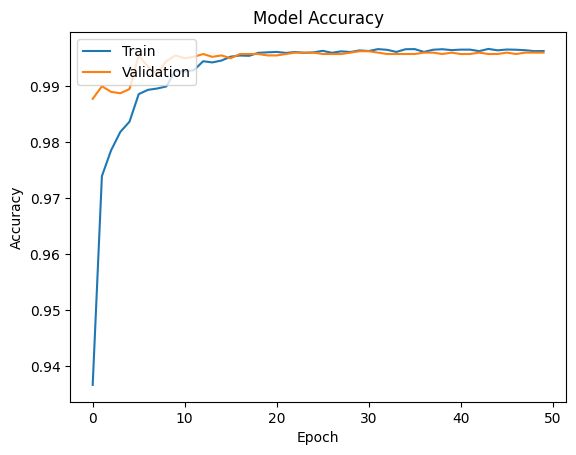

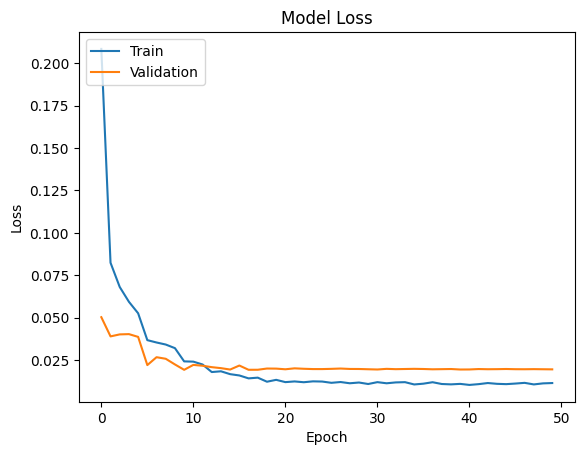

In [17]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Both training and validation accuracy rise steeply in the first few epochs showing rapid learning at the start. They start converging around epoch 15 onwards and remaining stable for the rest of the epochs. The loss meanwhile, drops instead of rise, rapidly in the first few epochs before again converging around 15 onwards then remaining stable for the rest of the epochs.